<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/BMW_Used_Car_Market_Analysis_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BMW Used Car Market Analysis Dataset


# Introduction & Insights
---

### **BMW Used Car Market Analysis: Valuation, Depreciation, and Deal Identification**

**Project Overview**
This project conducts a comprehensive analysis of the BMW used car market, utilizing a dataset containing thousands of listings with attributes including model, mileage, year, engine size, transmission, and fuel type. The primary objective was to move beyond simple descriptive statistics to build a robust **Price Valuation System** capable of identifying market inefficiencies (undervalued cars) and quantifying depreciation trends.

**Key Insights & Market Dynamics**
Through Exploratory Data Analysis (EDA) and Feature Engineering, several critical market behaviors were uncovered:

1. **The Depreciation "Cliff":** Analysis of the price-to-age relationship revealed a non-linear depreciation curve. BMW vehicles typically experience their steepest value loss within the first three years (the "Depreciation Cliff"). However, the curve flattens significantly between years 5 and 7, identifying this as the optimal financial "sweet spot" for second-hand buyers seeking value retention.
2. **Model Hierarchy & Value Retention:** Statistical testing (ANOVA) confirmed significant pricing stratification between series. While the **1 Series** and **3 Series** serve as volume sellers with standard depreciation rates, the **X Series (SUVs)** demonstrated superior residual value retention, likely driven by high market demand for luxury SUVs.
3. **Feature Importance:** Using a **Random Forest Regressor**, we determined that *Car Age* and *Engine Size* are the most statistically significant predictors of price, outweighing even *Mileage* in certain contexts. This suggests that buyers are paying a premium for newer technology and performance over simple wear-and-tear metrics.
4. **Transmission Premium:** A T-Test confirmed a statistically significant price premium for Automatic transmissions over Manuals, reflecting the shifting consumer preference in the luxury sector.

**Machine Learning & Business Application**
The core of this project was the development of a predictive pricing model. By employing a Random Forest Regressor and utilizing Target Encoding for high-cardinality categorical variables (like distinct car models), the model achieved high accuracy in predicting fair market value.

This model was deployed as a **"Deal Finder" Algorithm** (Residual Analysis). By comparing the *Predicted Price* (AI estimate) against the *Actual Asking Price*, the system successfully identified listings that were significantly undervalued. This transforms the project from a theoretical analysis into a practical tool for arbitrage, capable of flagging "Great Deals" where the market has mispriced a vehicle based on its specs.

**Conclusion**
In conclusion, this analysis proves that the second-hand luxury car market follows predictable, data-driven patterns. By leveraging machine learning, we can not only quantify the cost of ownership (depreciation) but also systematically identify profitable buying opportunities that human intuition might miss.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d algozee/bmw-dataset

# Unziping the downloaded file
!unzip bmw-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/algozee/bmw-dataset
License(s): CC0-1.0
  0% 0.00/110k [00:00<?, ?B/s]
100% 110k/110k [00:00<00:00, 355MB/s]
Archive:  bmw-dataset.zip
  inflating: bmw.csv                 


# Data Inspection

In [3]:
df = pd.read_csv('bmw.csv')
df.head(11)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,14250,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,14250,Automatic,36099,Diesel,20,68.9,2.0


In [4]:
df.tail(11)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
10770,7 Series,2008,6480,Automatic,70500,Diesel,325,35.3,3.0
10771,5 Series,2015,11700,Automatic,106000,Diesel,160,51.4,2.0
10772,1 Series,2017,10200,Manual,41435,Diesel,0,83.1,1.5
10773,X1,2017,15900,Automatic,60372,Diesel,125,57.6,2.0
10774,5 Series,2016,14300,Automatic,67530,Diesel,30,62.8,2.0
10775,X4,2015,20000,Automatic,44147,Diesel,200,47.9,3.0
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [5]:
df.shape

(10781, 9)

In [6]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [7]:
df.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,10781,24,3 Series,2443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,10781.0,NaN,NaN,NaN,2017.078935,2.349038,1996.0,2016.0,2017.0,2019.0,2020.0
price,10781.0,NaN,NaN,NaN,22733.408867,11415.528189,1200.0,14950.0,20462.0,27940.0,123456.0
transmission,10781,3,Semi-Auto,4666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,10781.0,NaN,NaN,NaN,25496.98655,25143.192559,1.0,5529.0,18347.0,38206.0,214000.0
fuelType,10781,5,Diesel,7027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,10781.0,NaN,NaN,NaN,131.702068,61.510755,0.0,135.0,145.0,145.0,580.0
mpg,10781.0,NaN,NaN,NaN,56.399035,31.336958,5.5,45.6,53.3,62.8,470.8
engineSize,10781.0,NaN,NaN,NaN,2.167767,0.552054,0.0,2.0,2.0,2.0,6.6


In [10]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [11]:
df.duplicated().sum()

np.int64(117)

# Statistical Analysis

In [21]:
from scipy.stats import ttest_ind, f_oneway

# --- 1. T-Test: Manual vs Automatic Price ---
# We select the prices for two groups
manual_prices = df[df['transmission'] == 'Manual']['price']
auto_prices = df[df['transmission'] == 'Automatic']['price']

# Run the T-test
t_stat, p_val = ttest_ind(auto_prices, manual_prices, equal_var=False)

print(f"--- T-Test: Automatic vs Manual Prices ---")
print(f"Avg Automatic Price: £{auto_prices.mean():,.0f}")
print(f"Avg Manual Price:    £{manual_prices.mean():,.0f}")
print(f"P-Value: {p_val:.5f}")

if p_val < 0.05:
    print("Result: Significant Difference! (Automatics are priced differently)")
else:
    print("Result: No Significant Difference found.")

--- T-Test: Automatic vs Manual Prices ---
Avg Automatic Price: £22,419
Avg Manual Price:    £14,637
P-Value: 0.00000
Result: Significant Difference! (Automatics are priced differently)



--- ANOVA Test: 1 Series vs 3 Series vs 5 Series ---
P-Value: 0.00000
Result: Significant Difference! (The Series number definitely affects price)


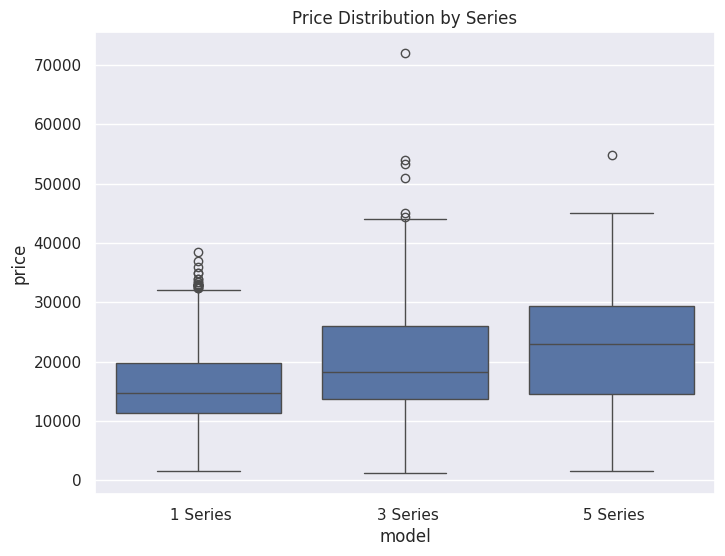

In [22]:
# --- 2. ANOVA: Comparing Multiple Models ---
# Let's compare the 3 most popular series: 1 Series, 3 Series, 5 Series
series_1 = df[df['model'].str.contains('1 Series')]['price']
series_3 = df[df['model'].str.contains('3 Series')]['price']
series_5 = df[df['model'].str.contains('5 Series')]['price']

# Run ANOVA
f_stat, p_val_anova = f_oneway(series_1, series_3, series_5)

print(f"\n--- ANOVA Test: 1 Series vs 3 Series vs 5 Series ---")
print(f"P-Value: {p_val_anova:.5f}")

if p_val_anova < 0.05:
    print("Result: Significant Difference! (The Series number definitely affects price)")

# Visual Proof
plt.figure(figsize=(8, 6))
# Create a small subset for plotting
plot_data = df[df['model'].isin([' 1 Series', ' 3 Series', ' 5 Series'])]
sns.boxplot(data=plot_data, x='model', y='price', order=[' 1 Series', ' 3 Series', ' 5 Series'])
plt.title('Price Distribution by Series')
plt.show()

# Univariate Analysis

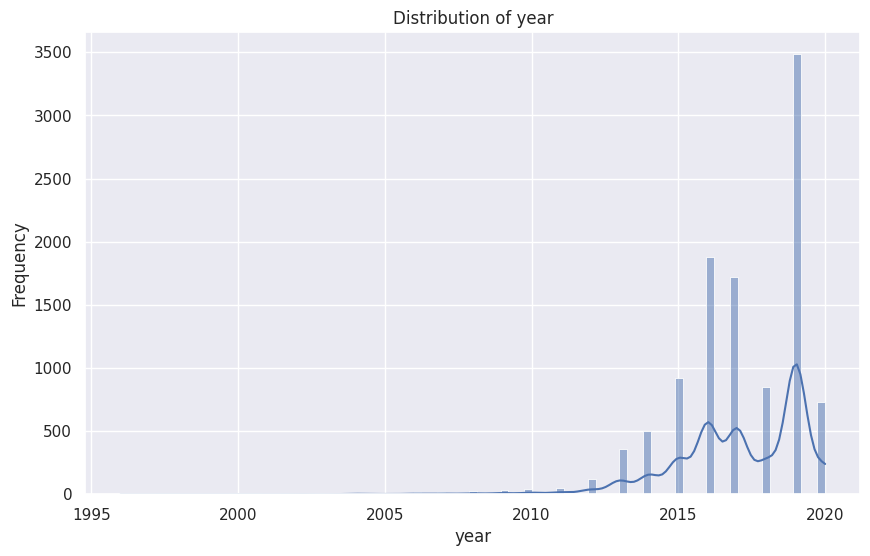

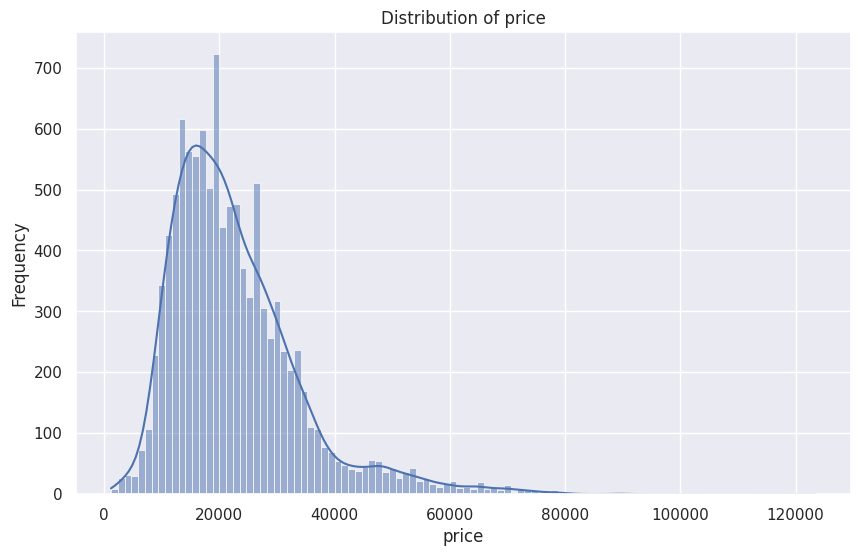

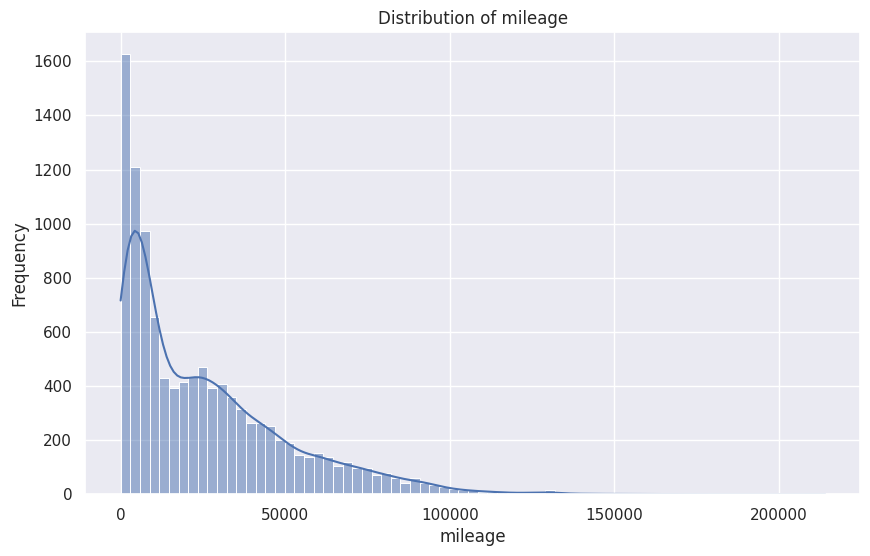

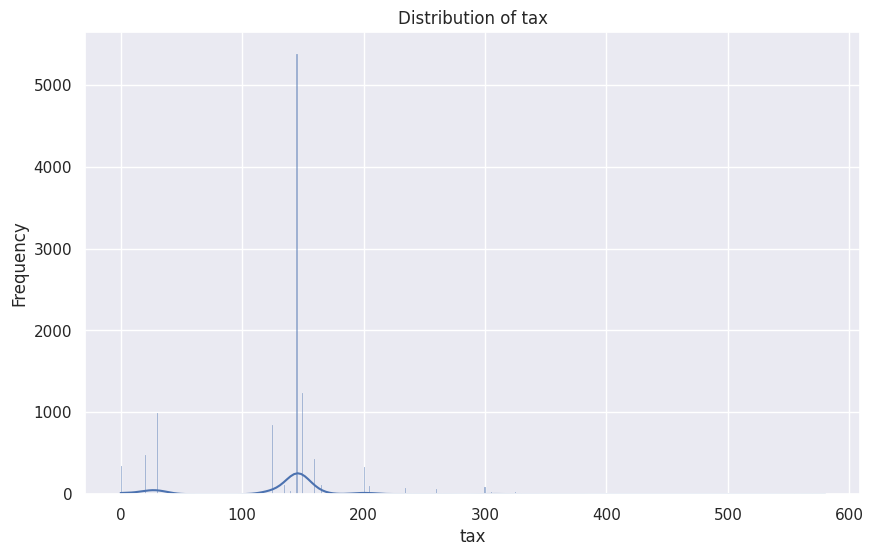

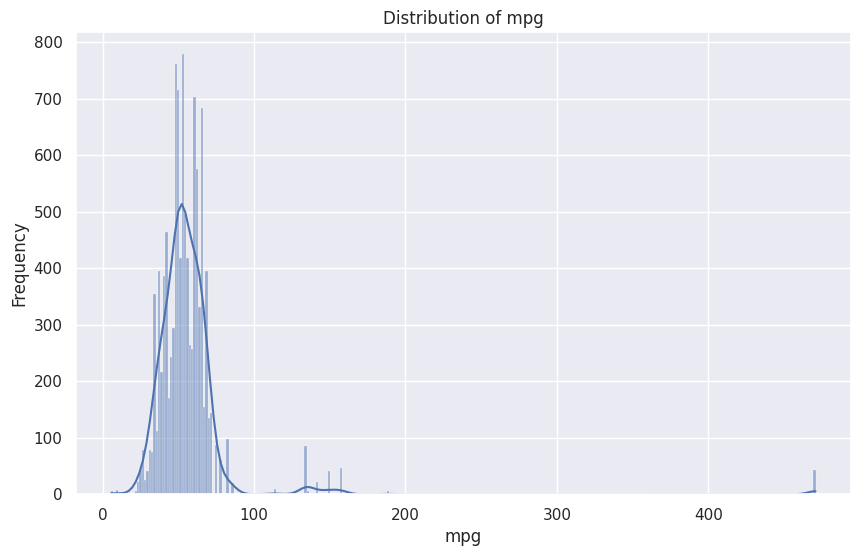

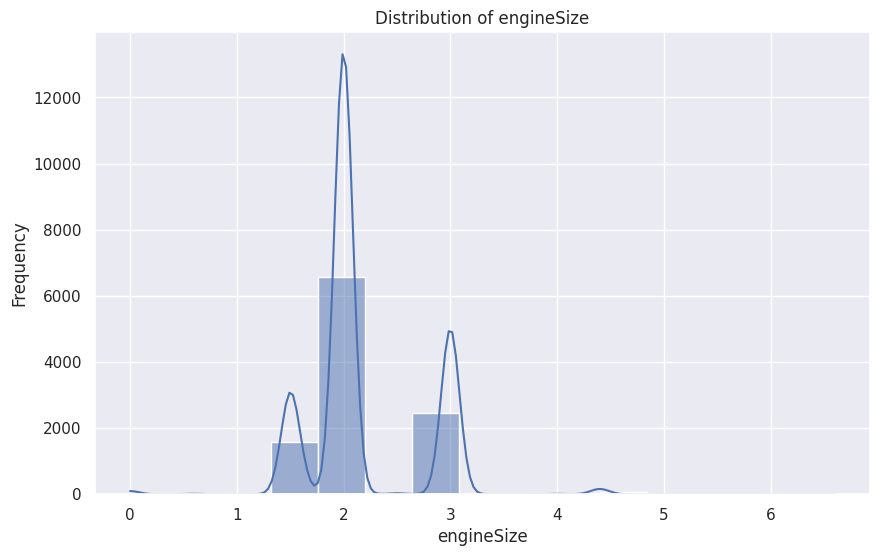

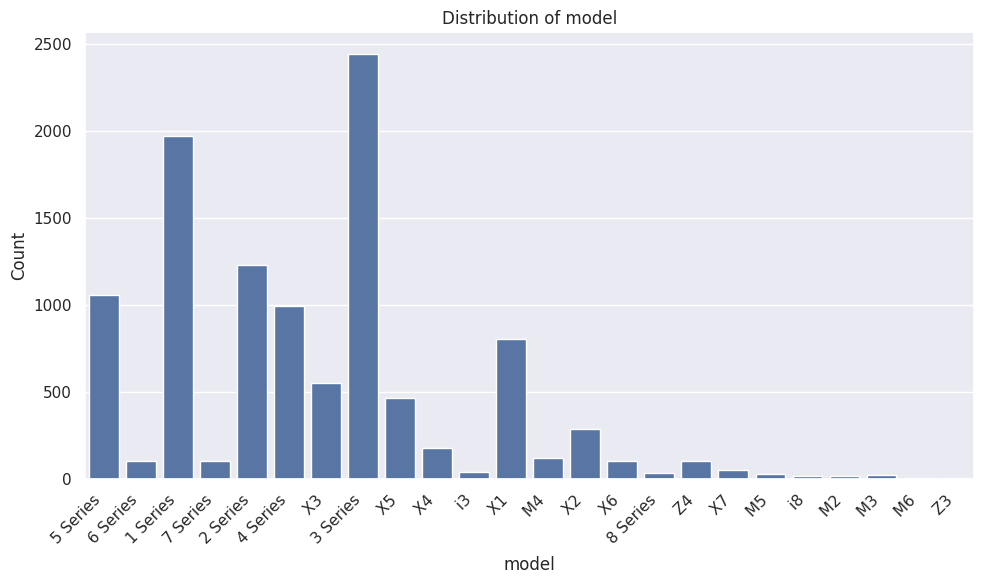

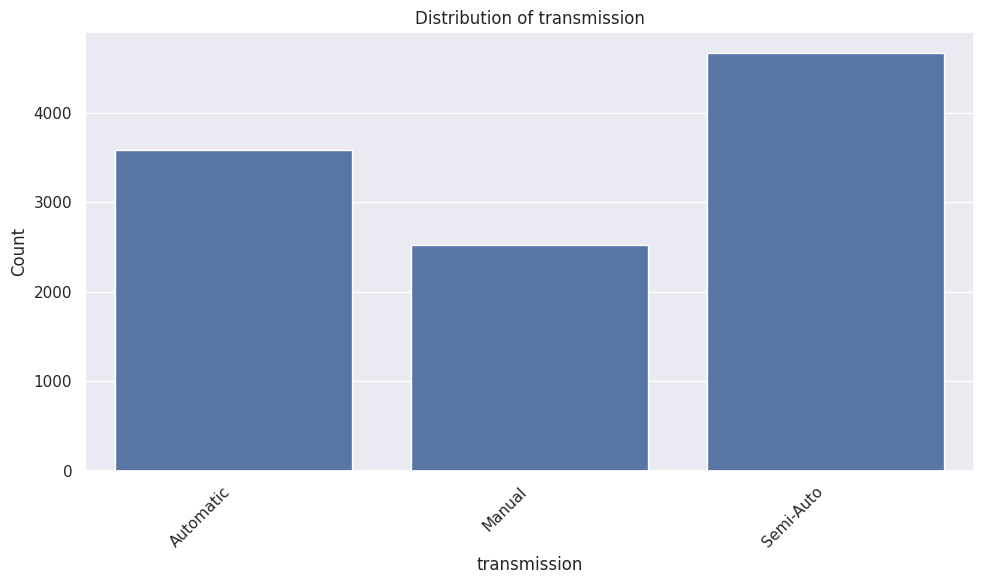

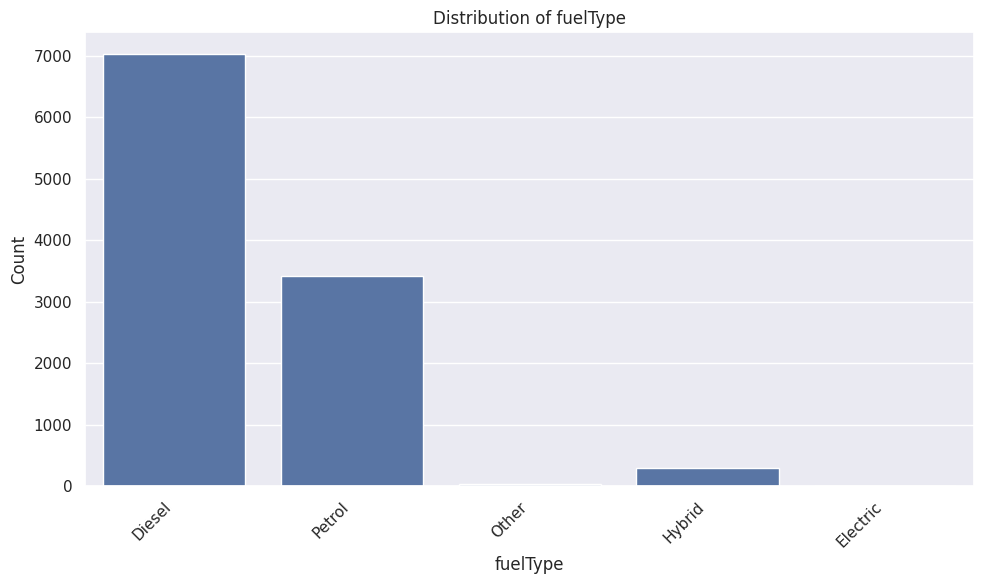

Value counts for model:
model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64

Value counts for transmission:
transmission
Semi-Auto    4666
Automatic    3588
Manual       2527
Name: count, dtype: int64

Value counts for fuelType:
fuelType
Diesel      7027
Petrol      3417
Hybrid       298
Other         36
Electric       3
Name: count, dtype: int64



In [12]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

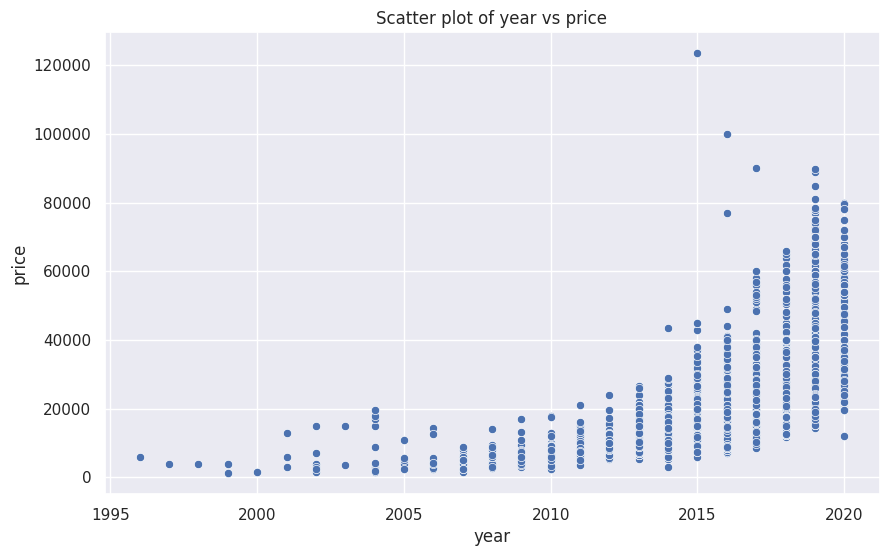

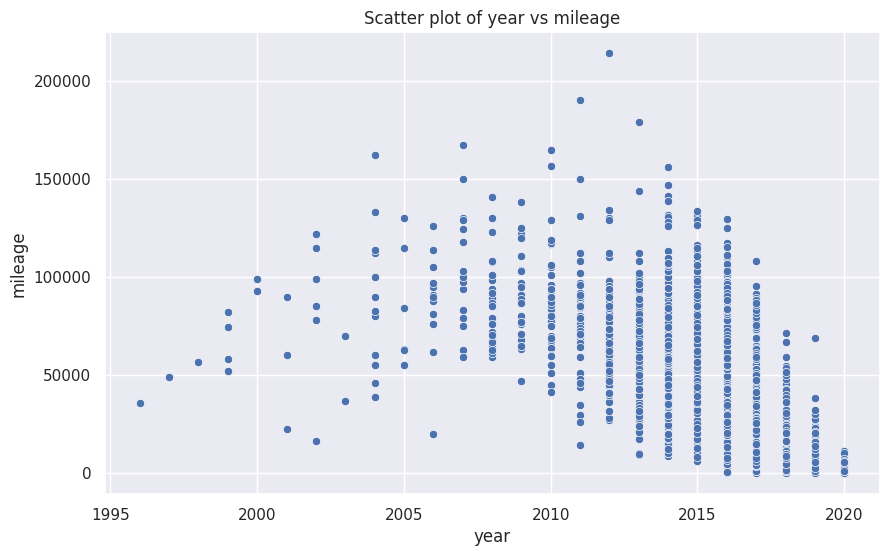

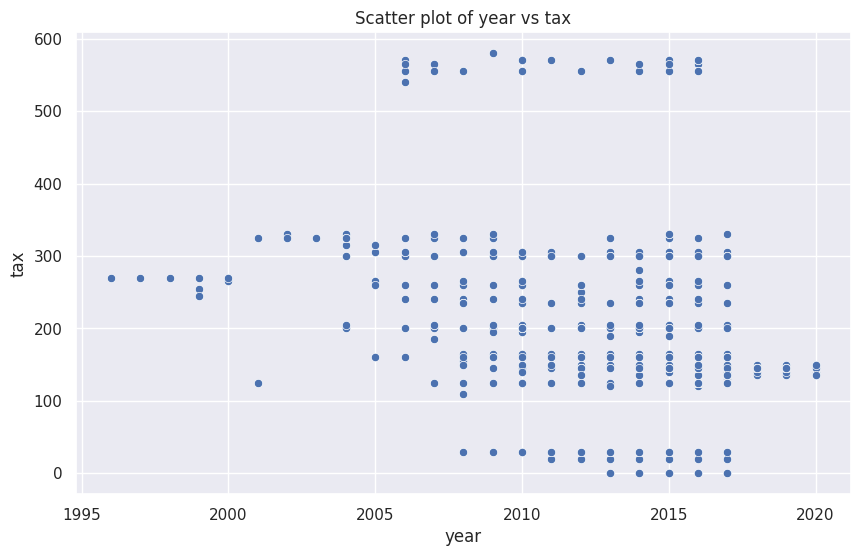

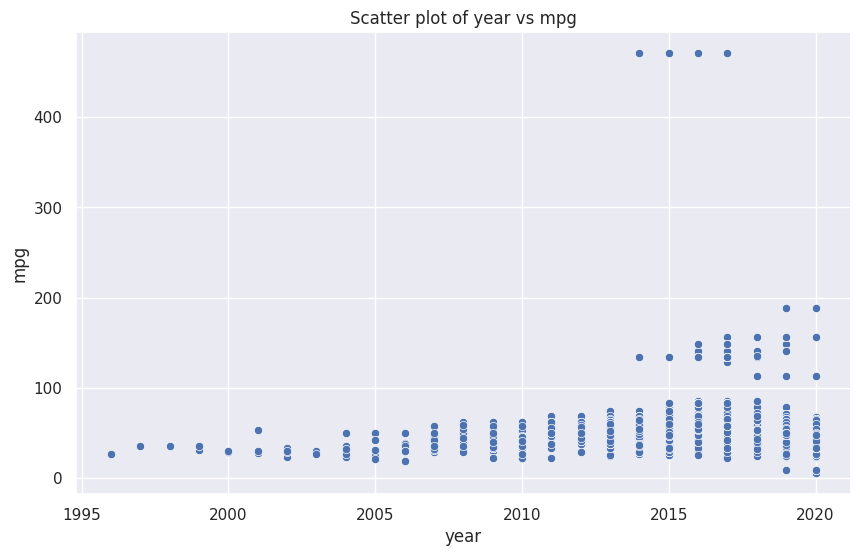

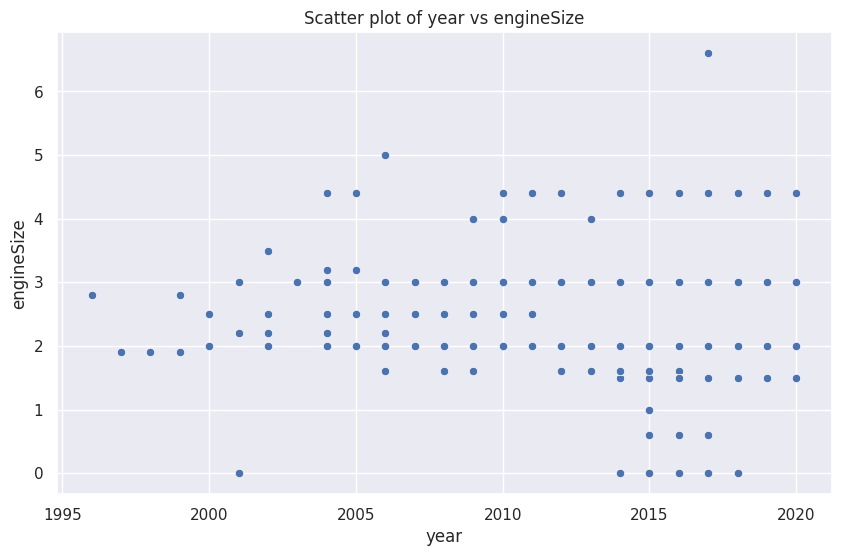

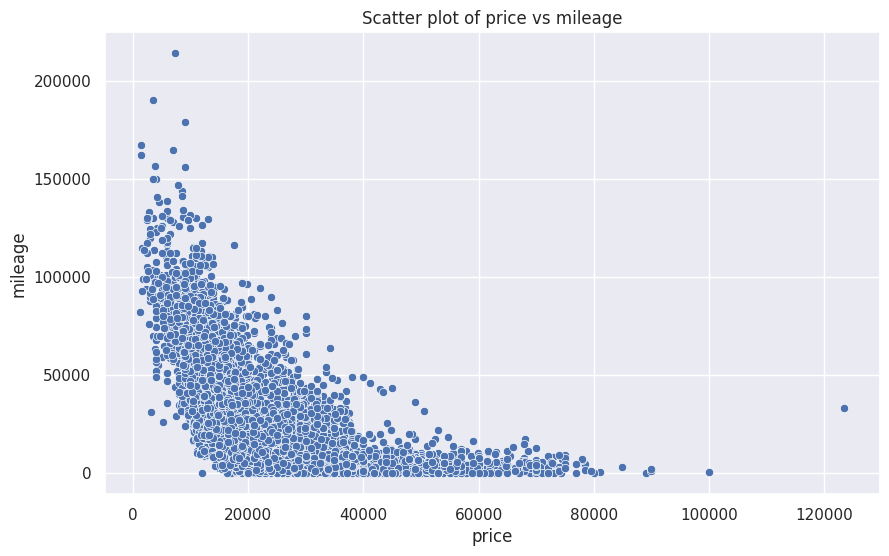

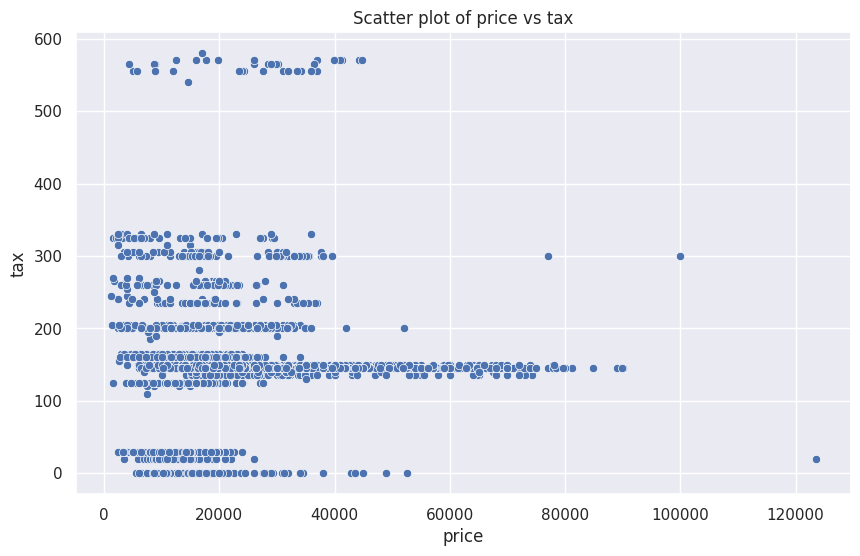

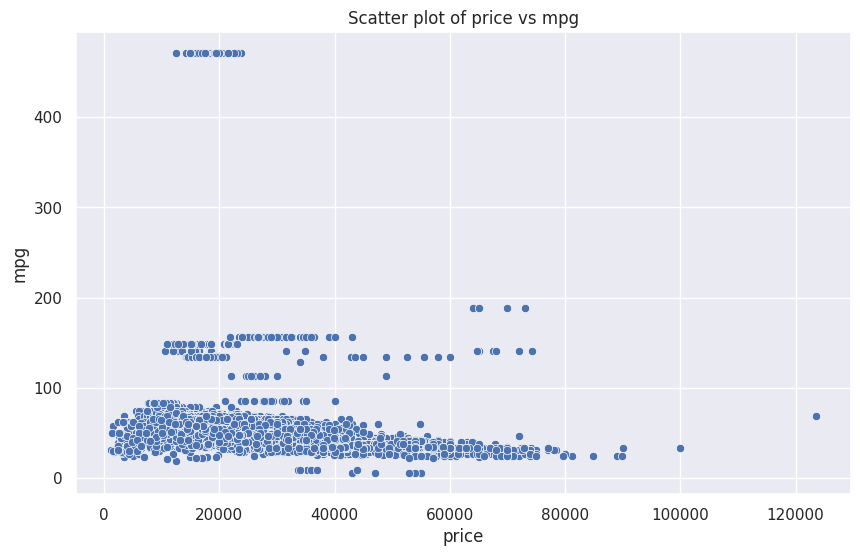

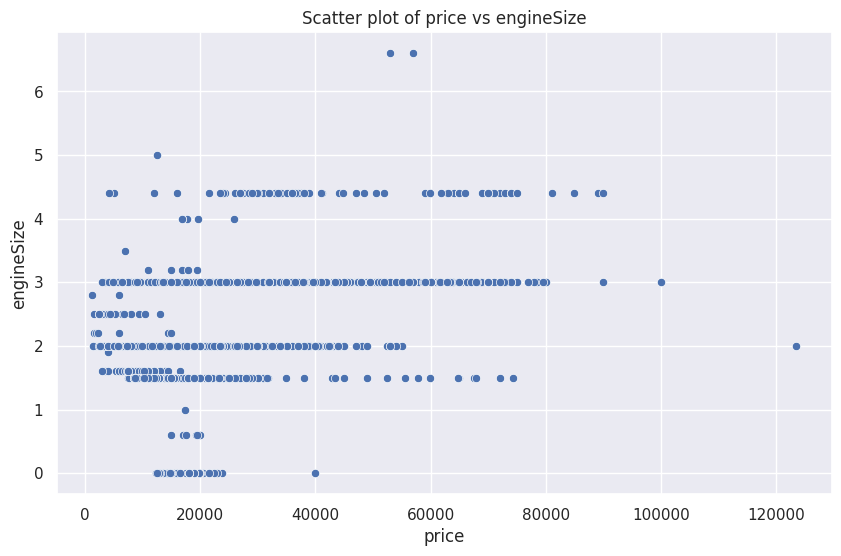

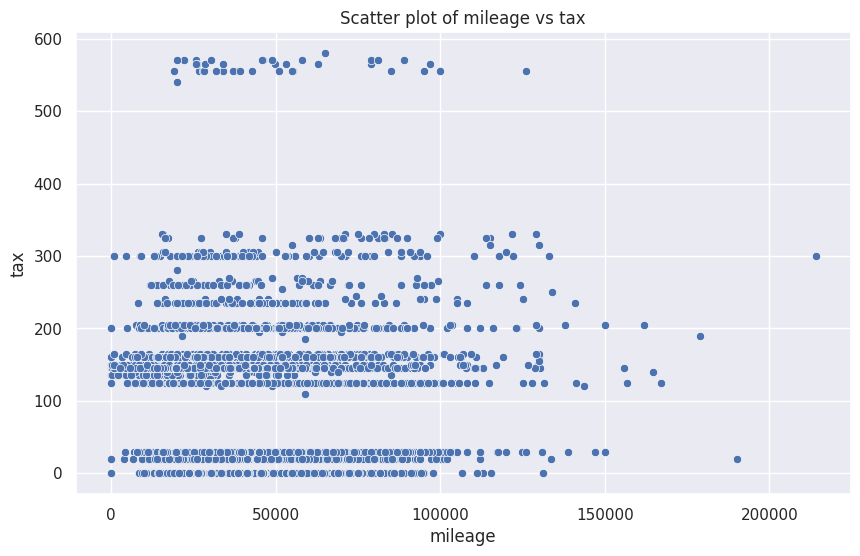

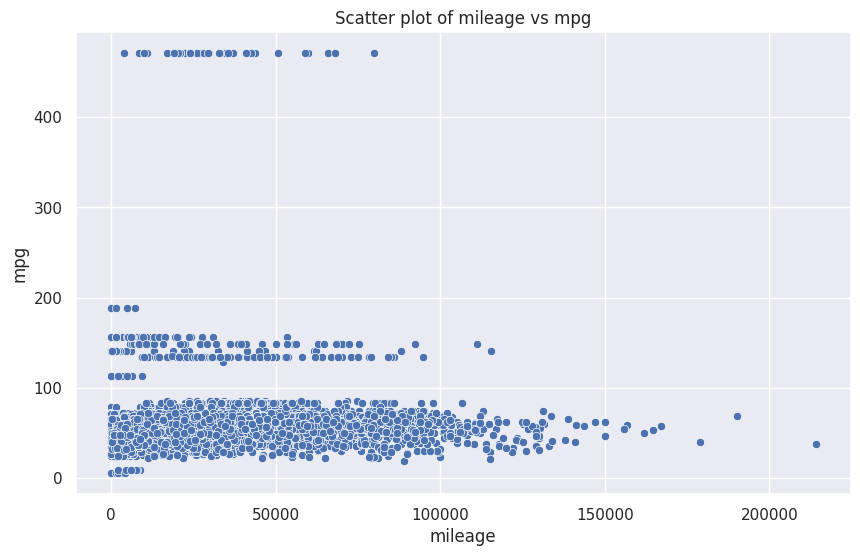

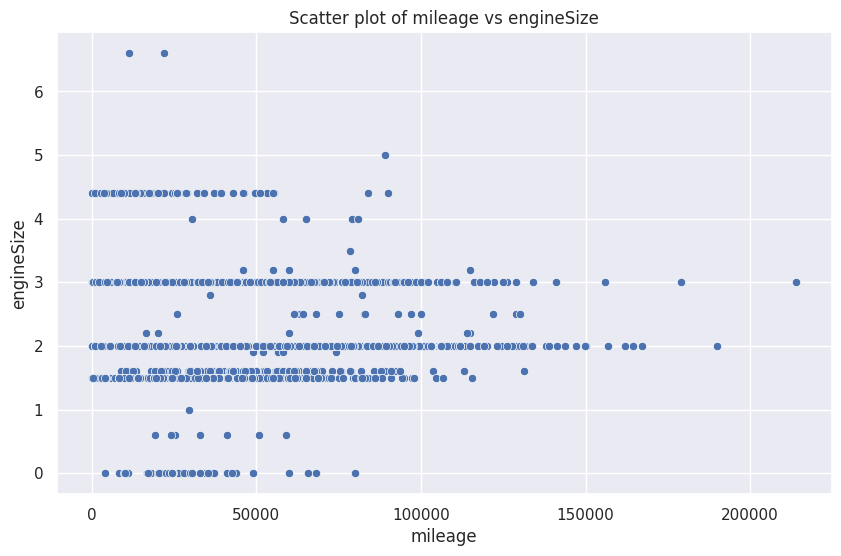

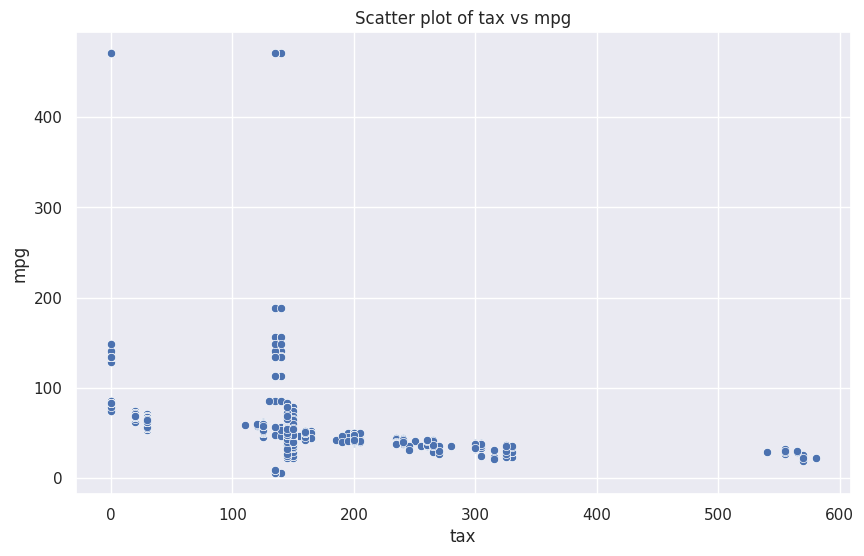

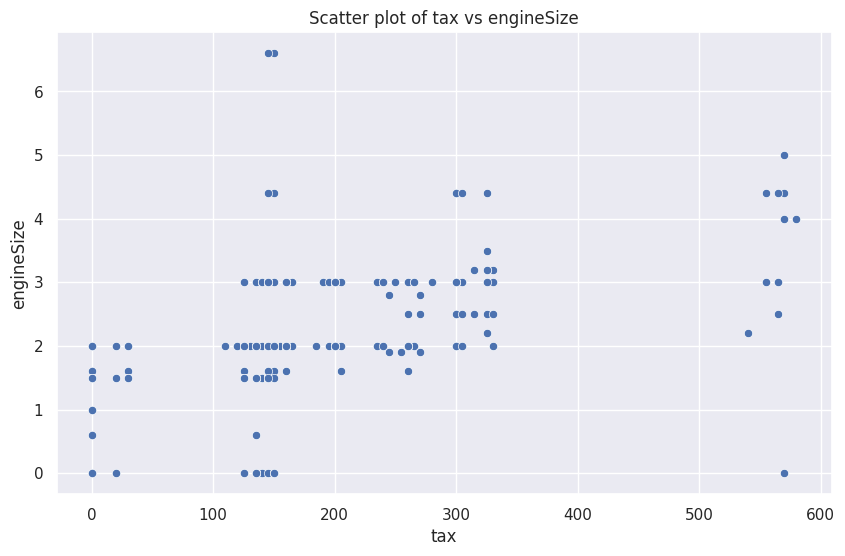

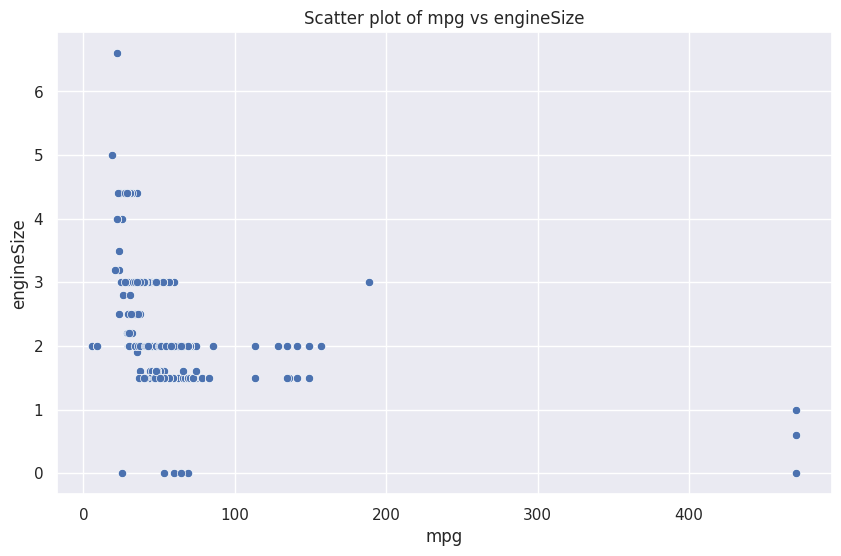

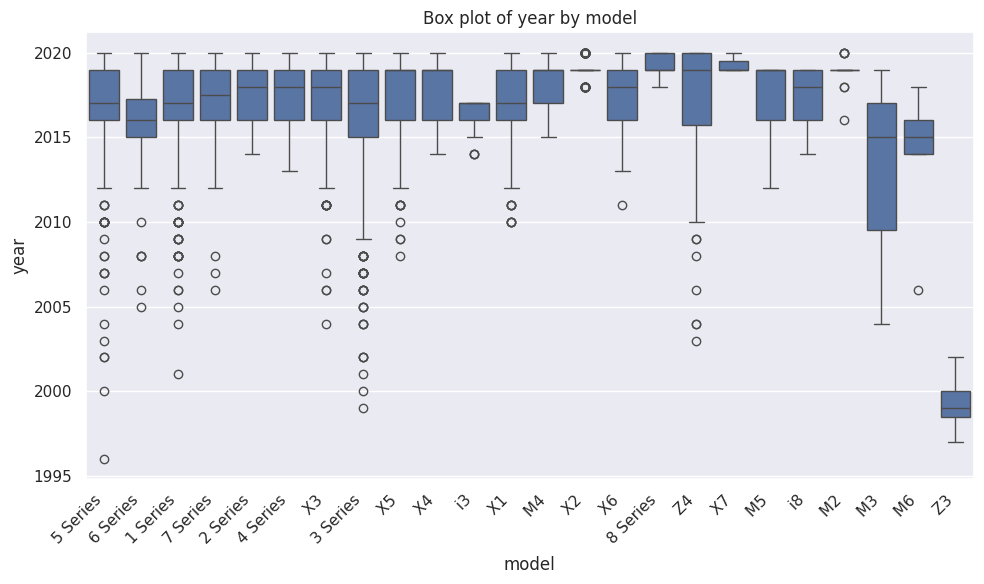

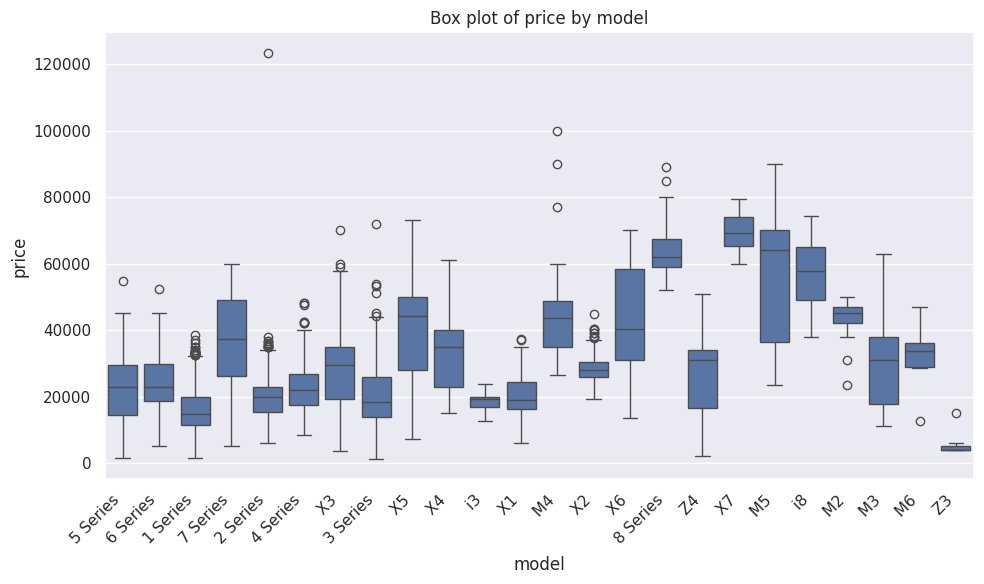

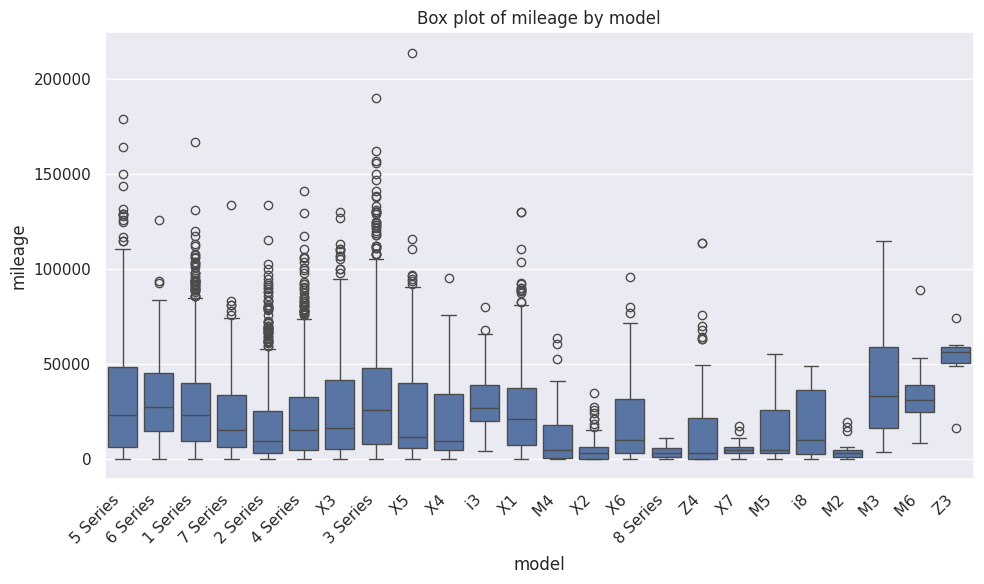

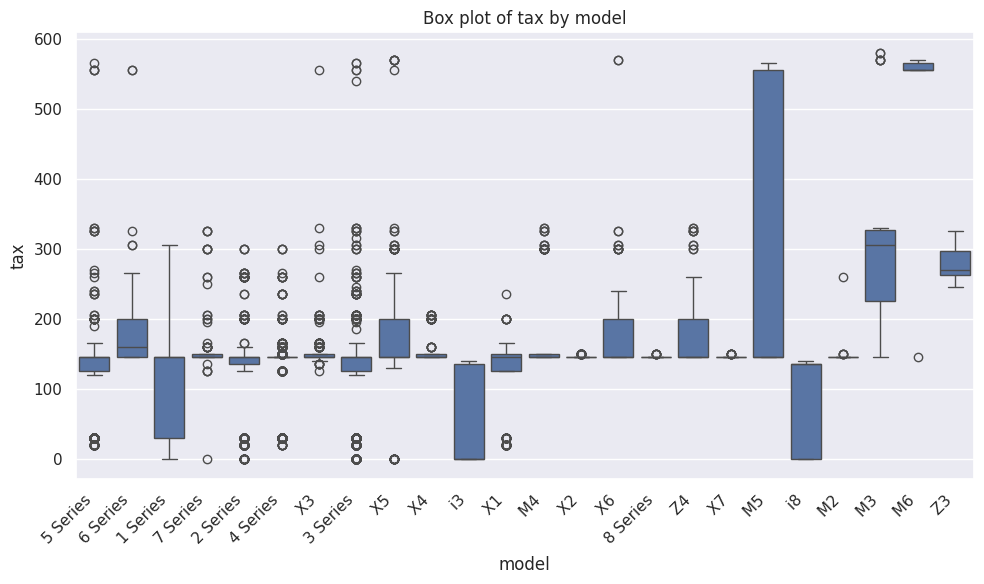

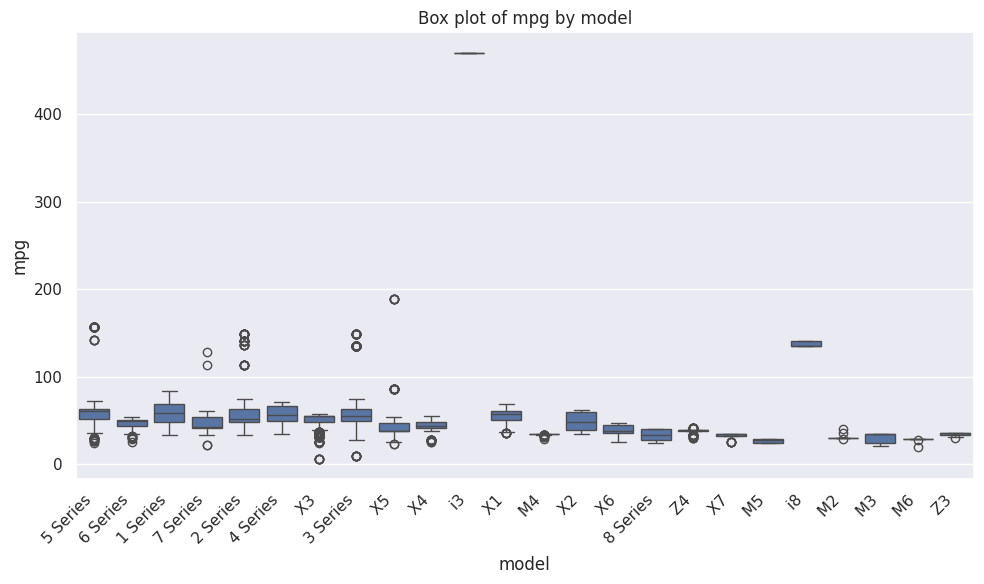

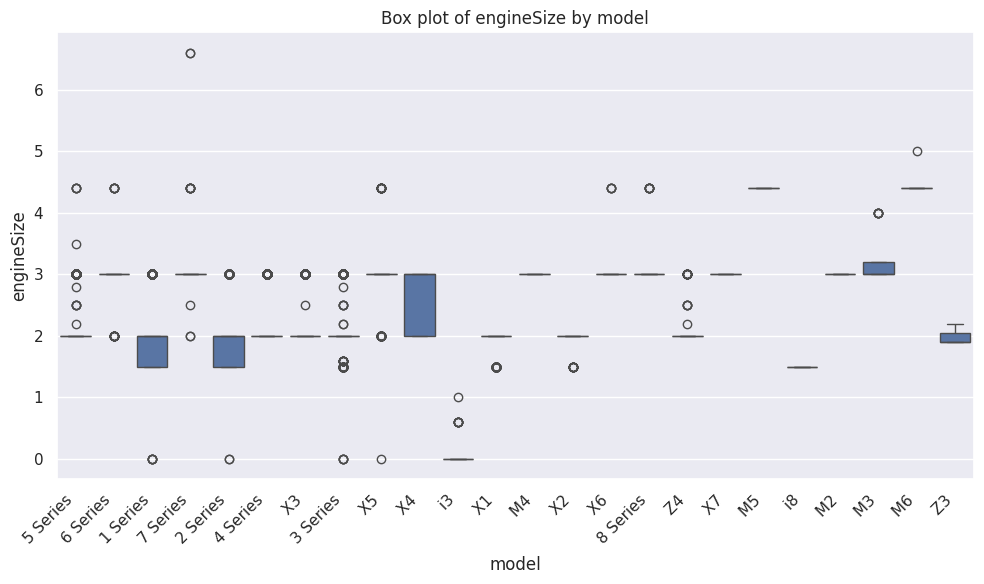

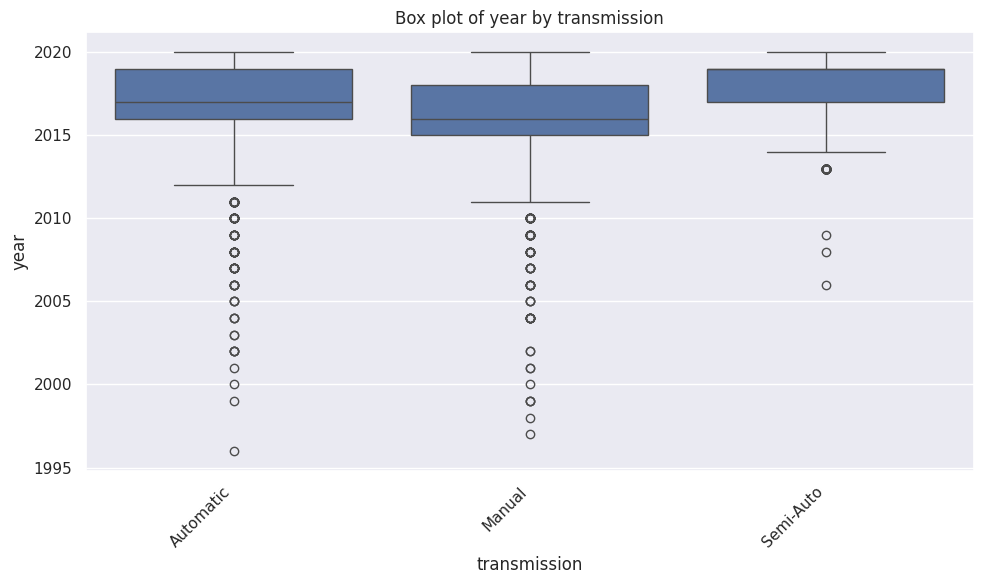

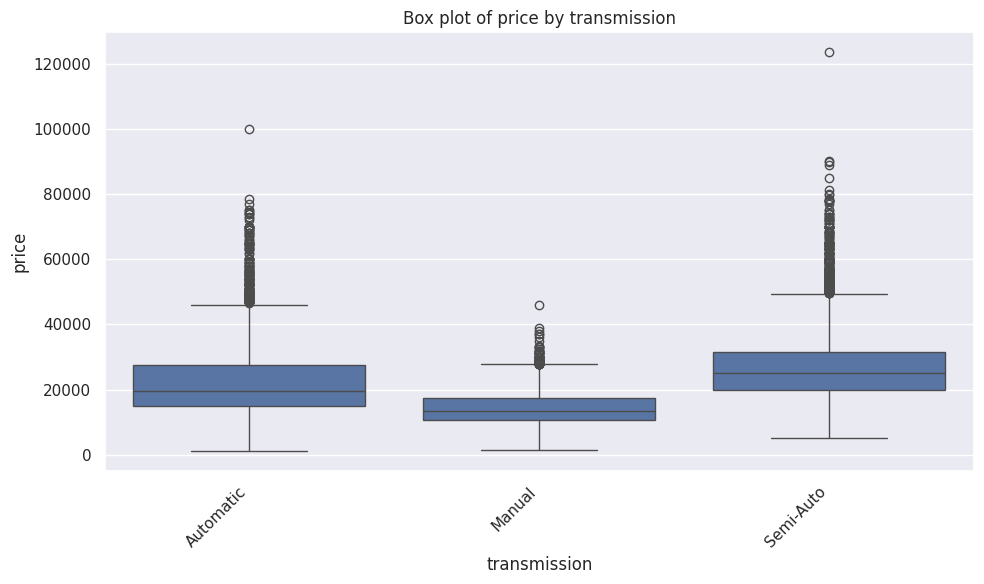

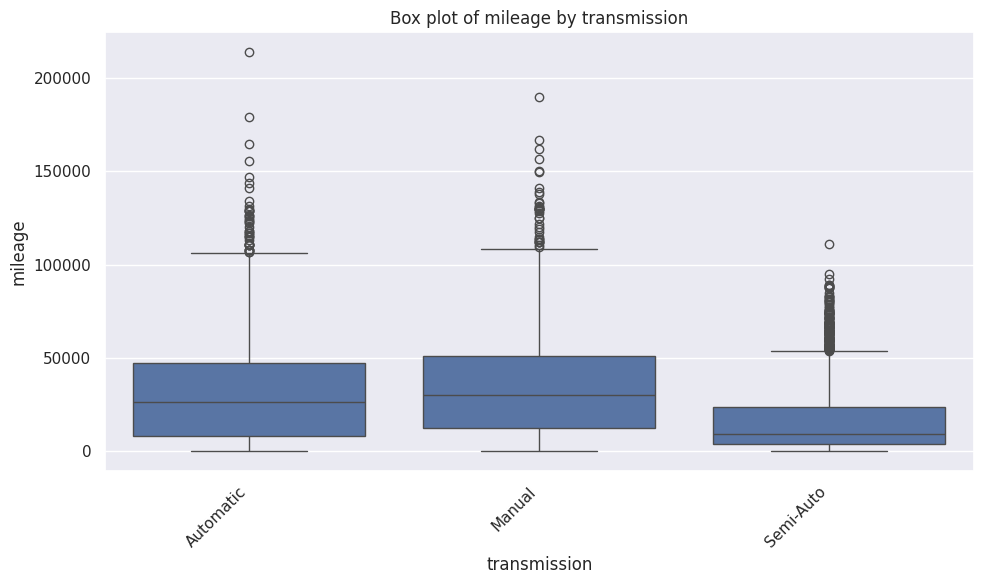

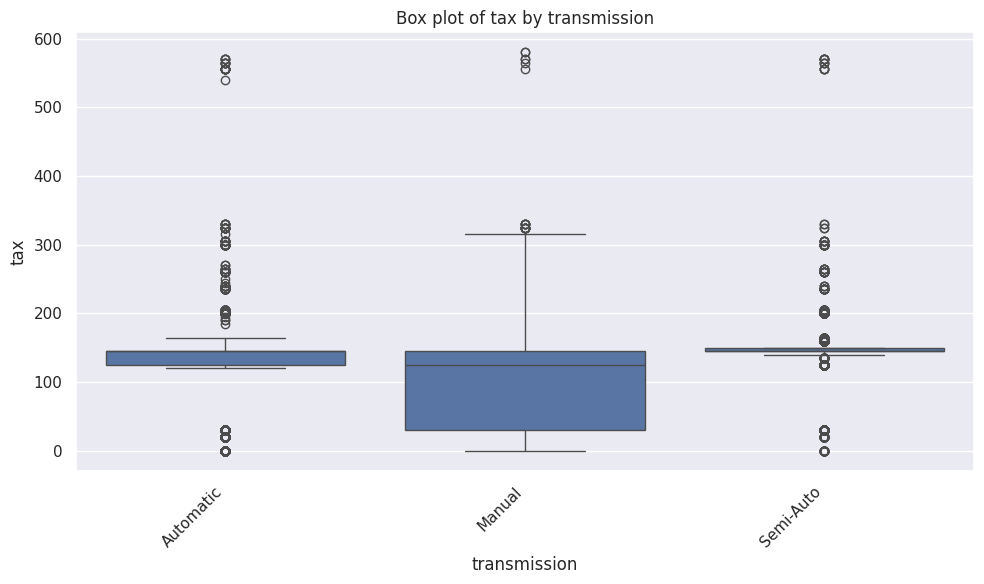

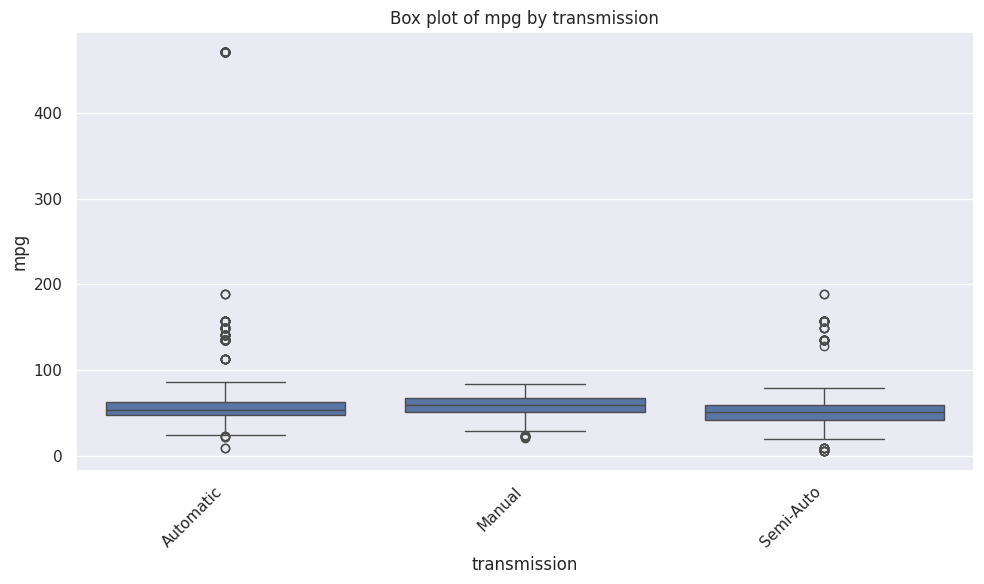

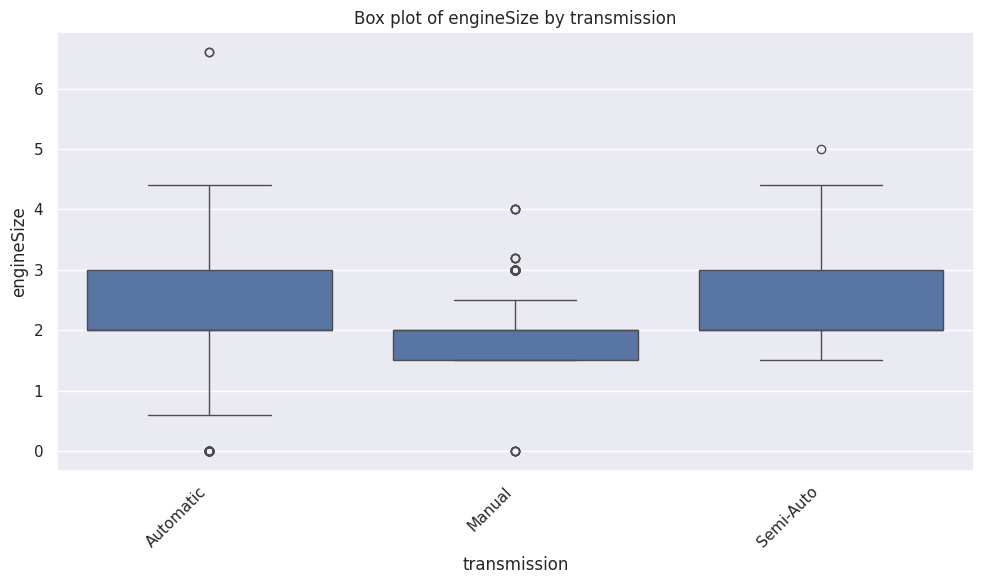

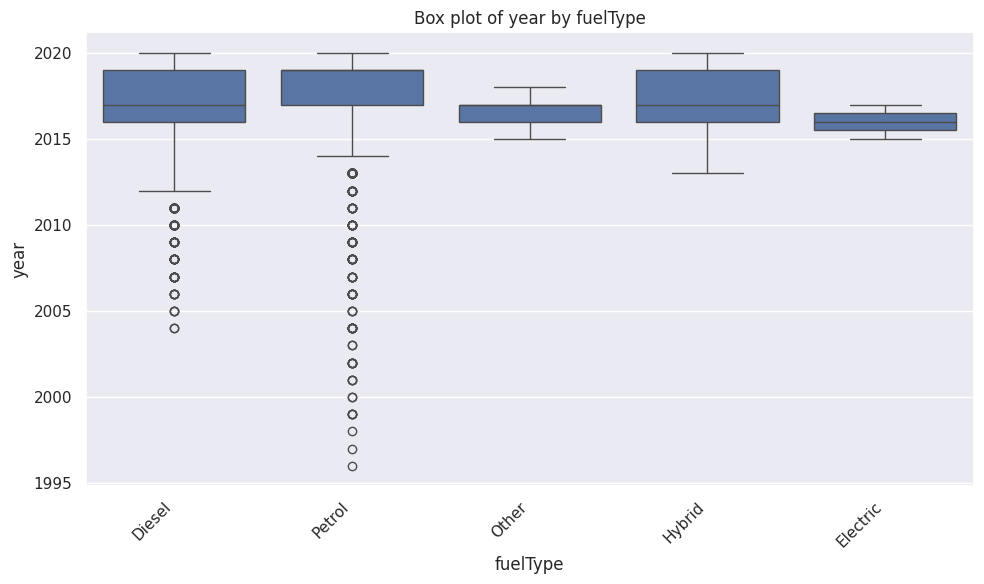

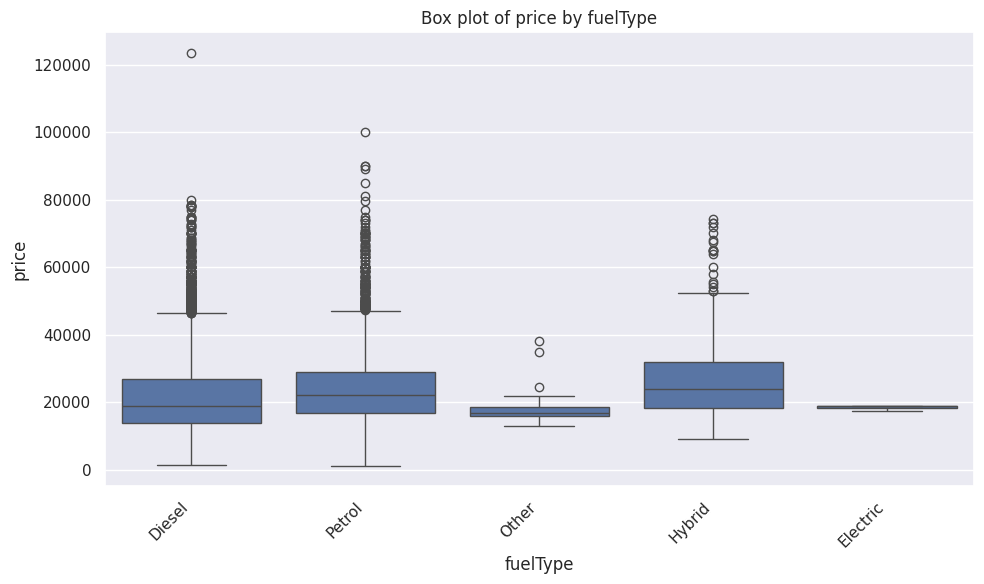

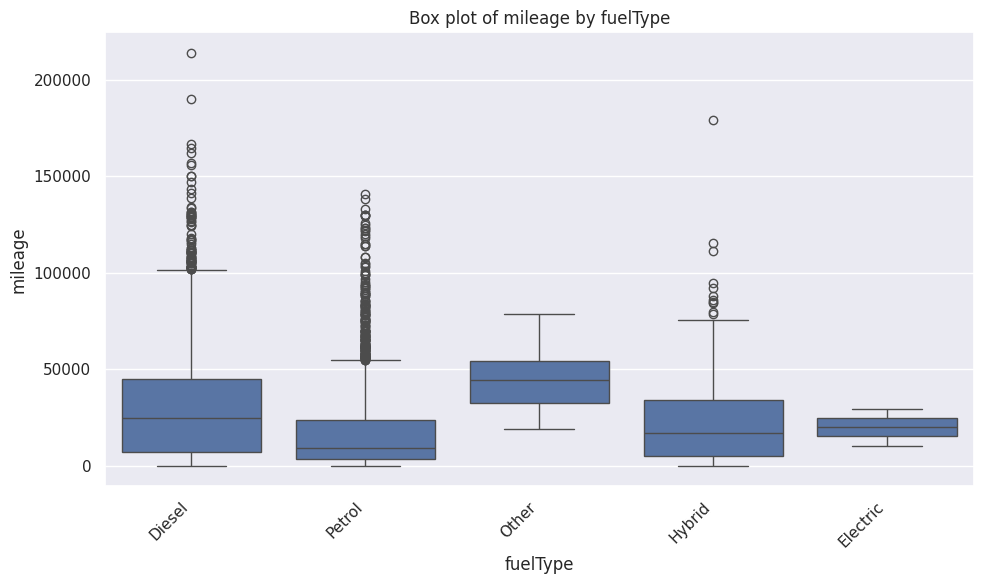

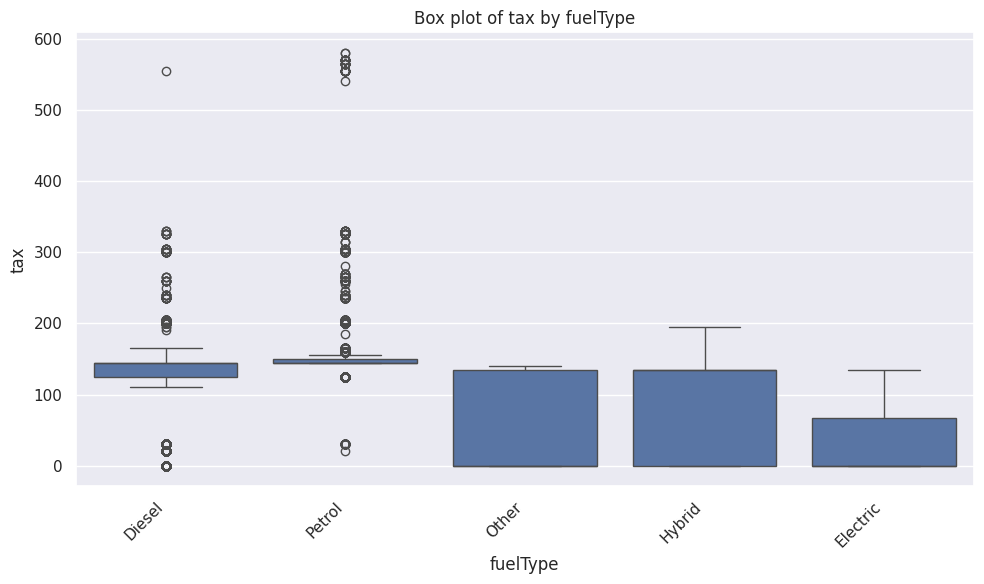

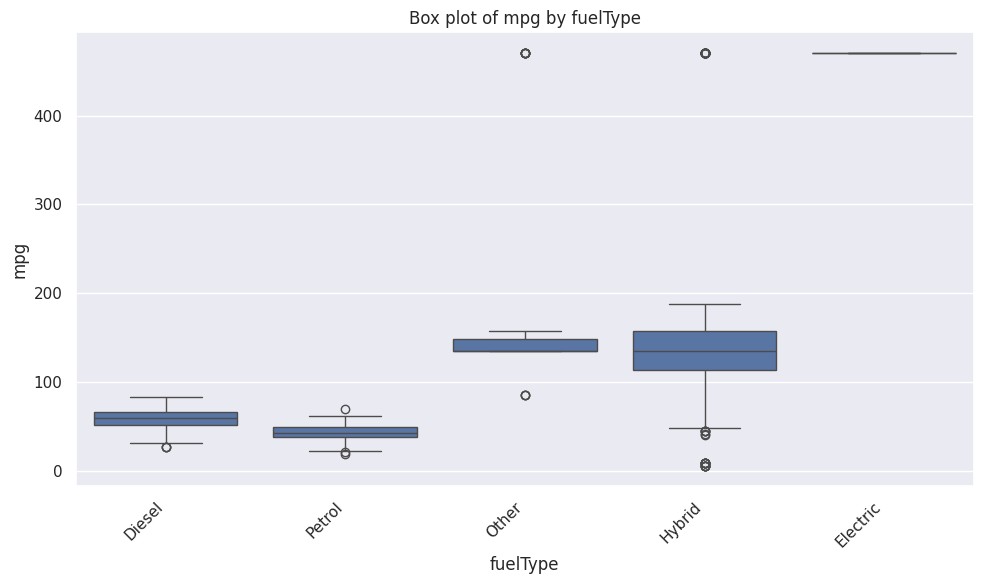

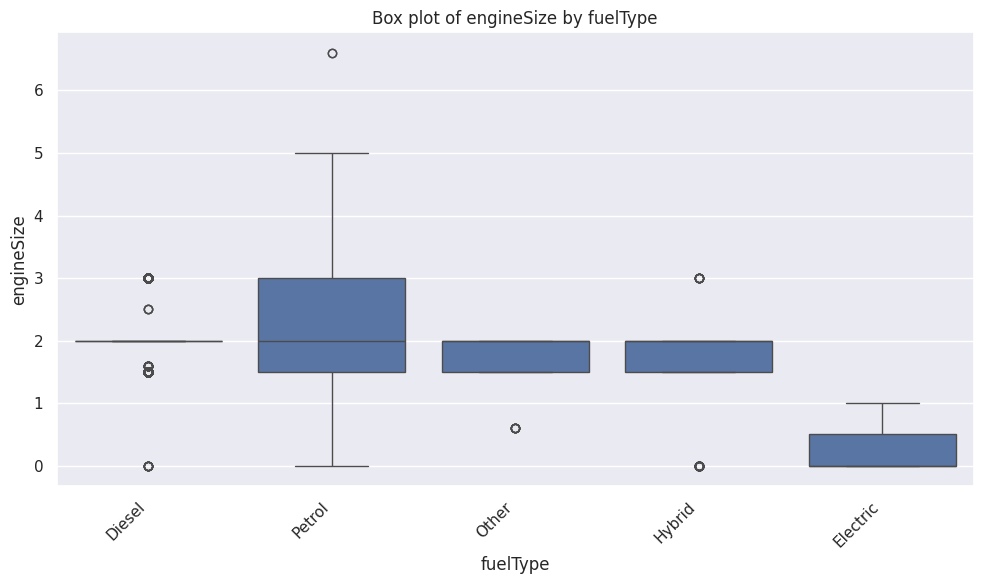

In [13]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


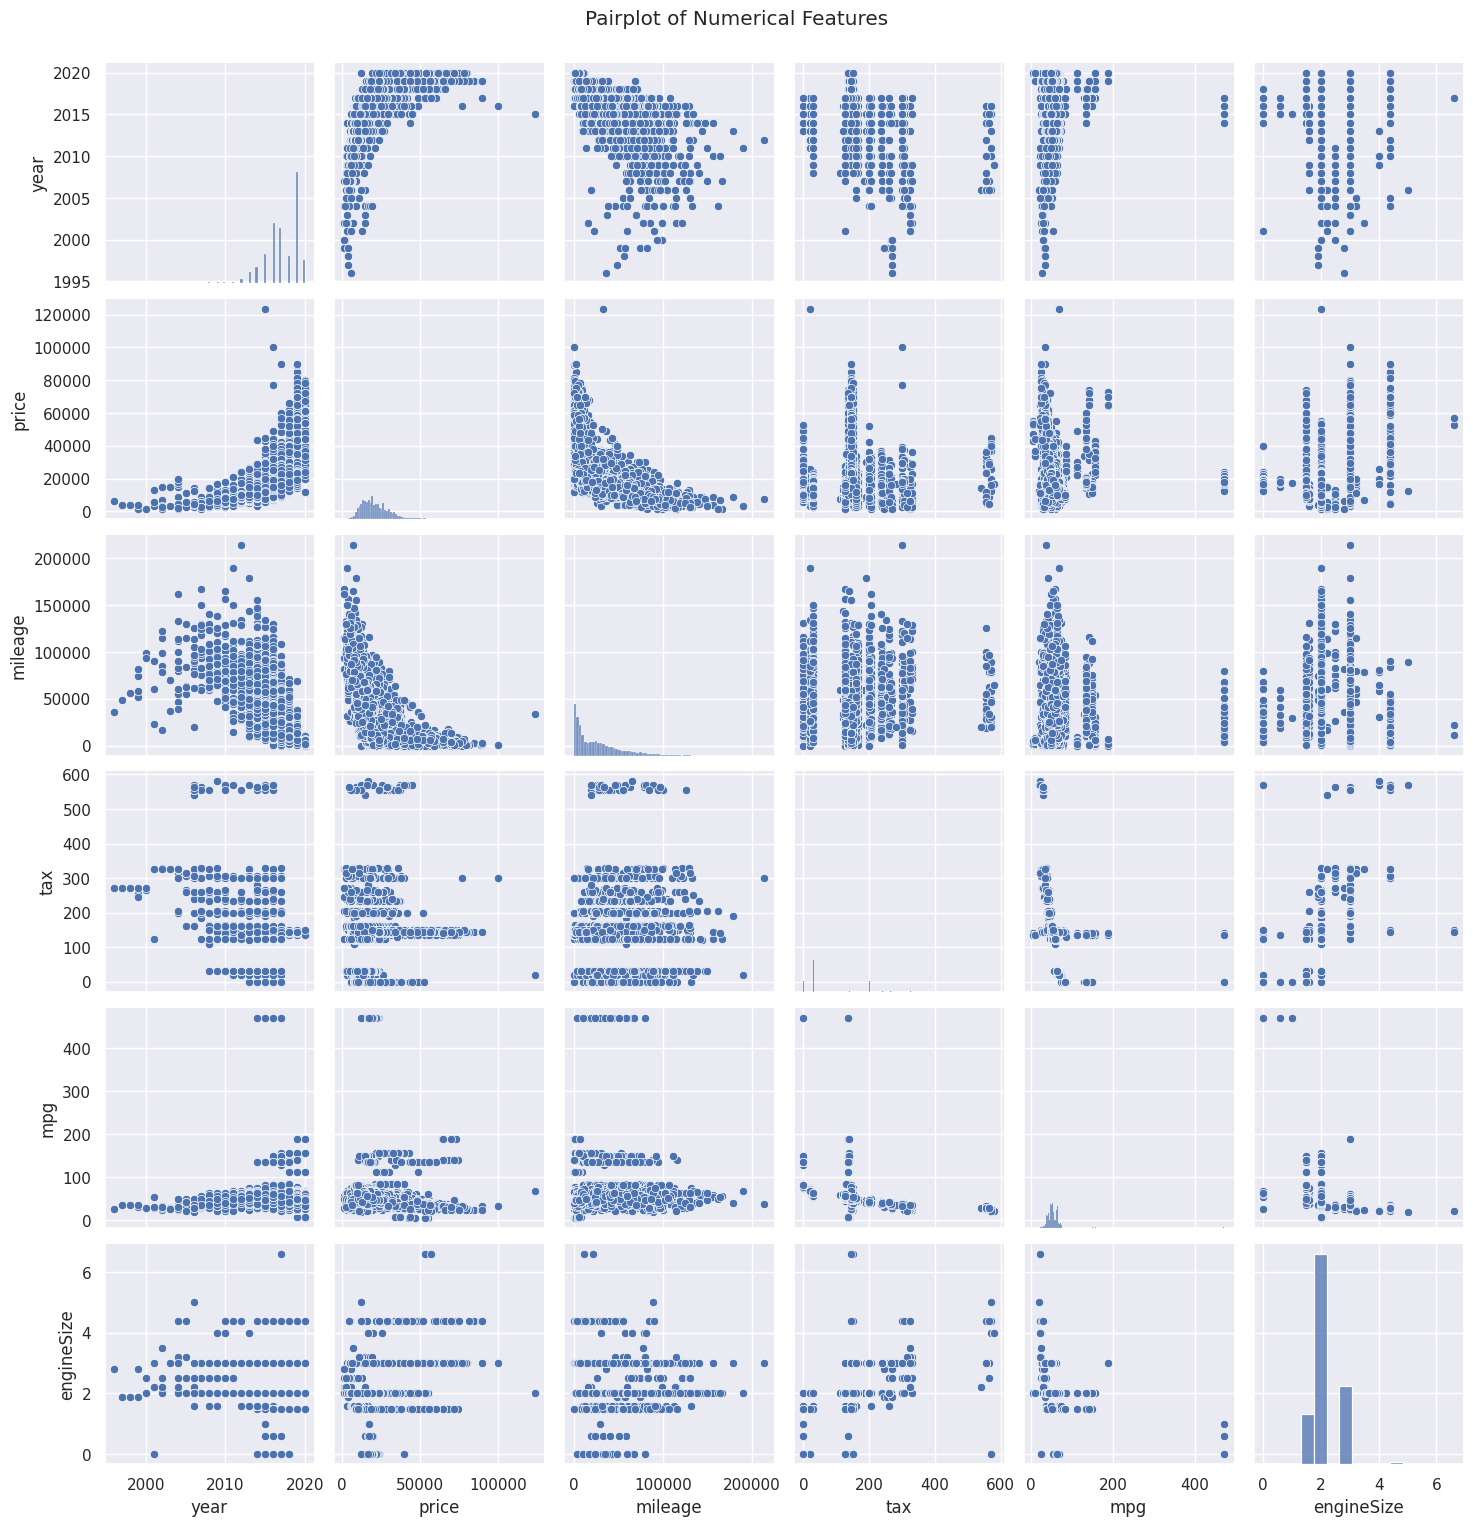

In [14]:
sns.pairplot(df.select_dtypes(include =  np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Machine Learning

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Data
df = pd.read_csv('bmw.csv')

# --- PREPROCESSING ---

# A. Feature Engineering (Creating 'Car_Age')
# Converting 'Year' to 'Age' is often better for models
current_year = 2025 # Adjust if needed
df['Car_Age'] = current_year - df['year']

# B. Encoding Categorical Variables
# 1. Transmission & FuelType: Few categories -> One-Hot Encoding
df_ml = pd.get_dummies(df, columns=['transmission', 'fuelType'], drop_first=True)

# 2. Model: Many categories (X1, X3, 3 Series, etc.) -> Target Encoding
# We replace the car model name with the "Average Price" of that model.
# This helps the machine understand that a "7 Series" is generally expensive.
model_price_map = df.groupby('model')['price'].mean()
df_ml['model_encoded'] = df['model'].map(model_price_map)

# Drop original 'model' and 'year' (since we have encoded model and Car_Age)
df_ml = df_ml.drop(columns=['model', 'year'])

# --- MODEL TRAINING ---

# Define Features (X) and Target (y)
X = df_ml.drop('price', axis=1)
y = df_ml['price']

# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Random Forest
# n_estimators=100 means we use 100 "decision trees"
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- EVALUATION ---

# Make Predictions
predictions = rf_model.predict(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: £{mae:,.0f}")
print(f"R² Score (Accuracy): {r2:.2%}")
print(f"Interpretation: On average, our model's price prediction is off by £{mae:,.0f}.")

--- Model Performance ---
Mean Absolute Error: £1,603
R² Score (Accuracy): 94.52%
Interpretation: On average, our model's price prediction is off by £1,603.


# Feature Importance & Prediction Accuracy

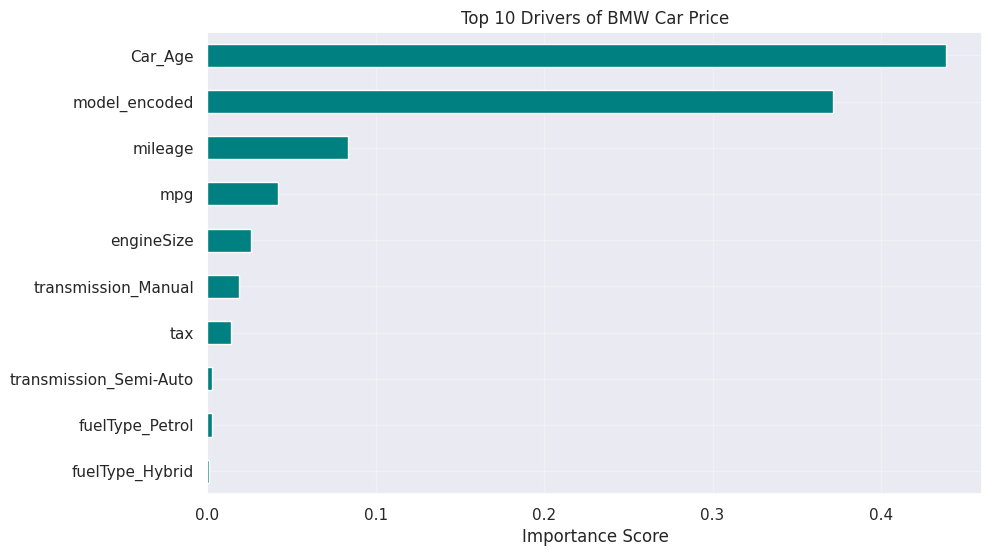

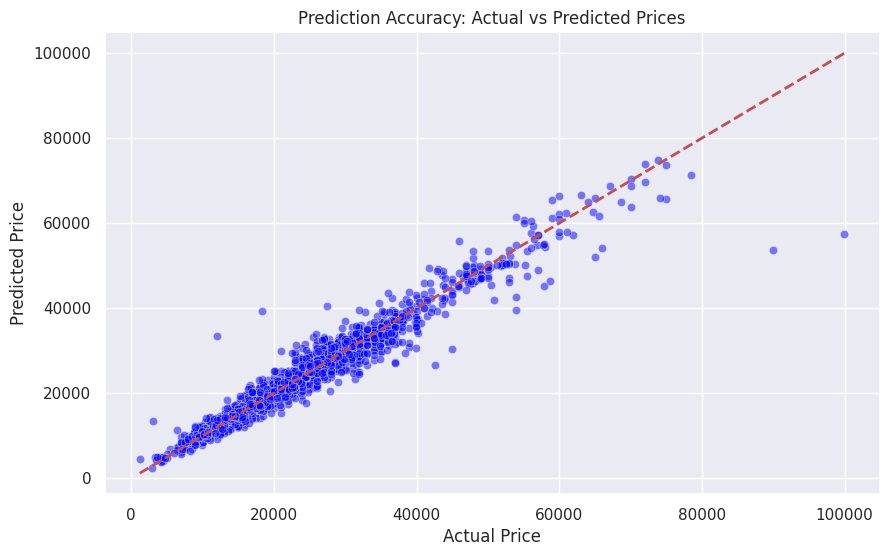

In [17]:
# 1. Feature Importance Plot

# What matters most? Mileage? Age? Engine Size?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of BMW Car Price')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis() # Put the most important at the top
plt.grid(True, alpha=0.3)
plt.show()

# 2. Actual vs Predicted Plot

# Do the dots follow the red line?
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, color='blue')
# Draw a perfect prediction line (Red)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Prediction Accuracy: Actual vs Predicted Prices')
plt.show()

# Depreciation Analysis

# Finding the top 5 most popular BMW models

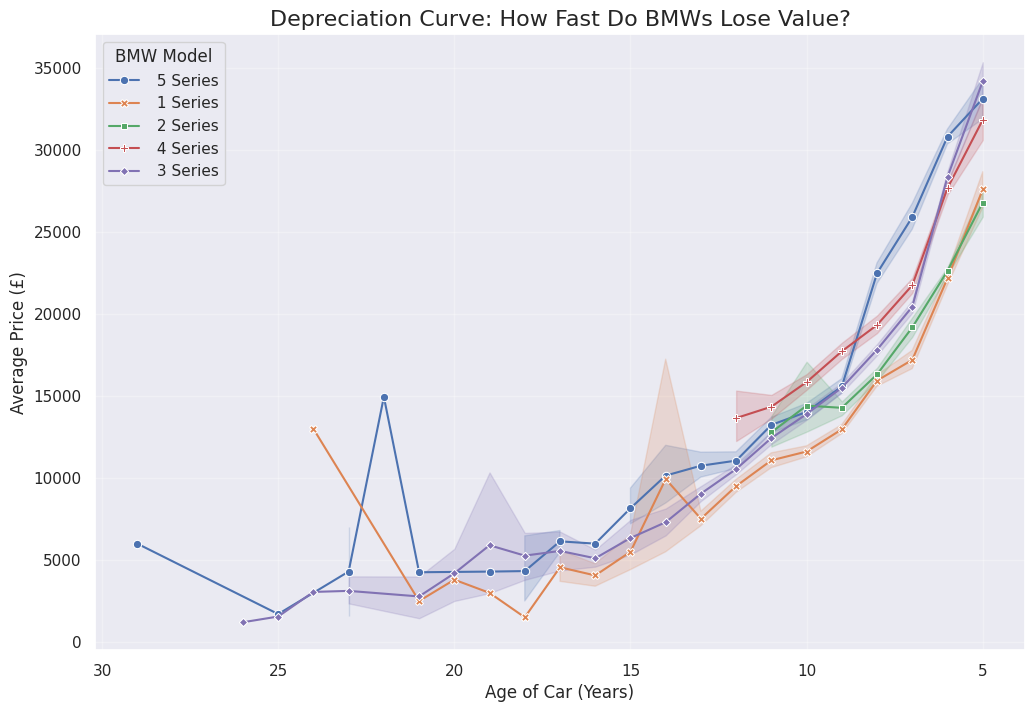

In [18]:
# 1. Prepare Data
# Create 'Car_Age' if you haven't already
current_year = 2025
df['Car_Age'] = current_year - df['year']

# 2. Select Top 5 Models
# We don't want to plot all 20+ models (too messy). Let's pick the most common ones.
top_models = df['model'].value_counts().head(5).index
df_filtered = df[df['model'].isin(top_models)]

# 3. Create the Depreciation Curve
plt.figure(figsize=(12, 8))

# We use a Line Plot with markers.
# Seaborn automatically calculates the 'Mean Price' for each year and draws a confidence interval (shadow).
sns.lineplot(data=df_filtered, x='Car_Age', y='price', hue='model', style='model', markers=True, dashes=False)

plt.title('Depreciation Curve: How Fast Do BMWs Lose Value?', fontsize=16)
plt.xlabel('Age of Car (Years)', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)
plt.legend(title='BMW Model')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis() # Optional: If you prefer seeing New -> Old (Age 0 -> 20)
plt.show()

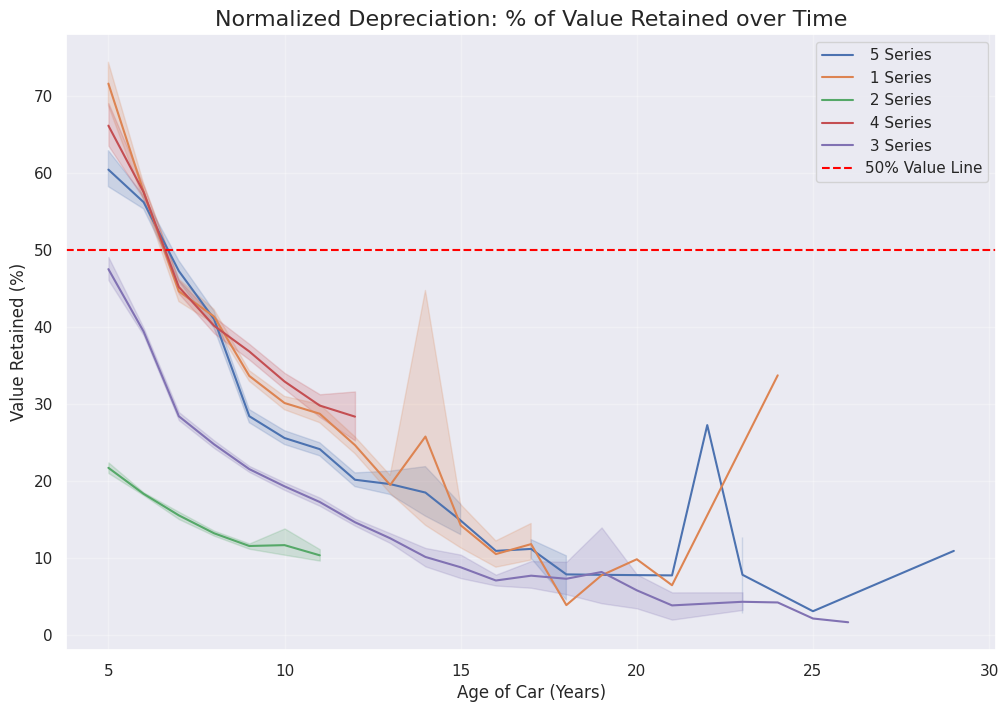

In [19]:
# Calculate % of Value Retained (Normalized)
# We assume the "Max Price" of a model (likely a new one) is 100% value.
# This isn't perfect (inflation exists), but it's a good proxy for depreciation speed.

df_norm = df_filtered.copy()
# Find the max price for each model (proxy for 'New Price')
max_prices = df_norm.groupby('model')['price'].transform('max')
df_norm['Value_Retained_Pct'] = (df_norm['price'] / max_prices) * 100

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_norm, x='Car_Age', y='Value_Retained_Pct', hue='model')

plt.title('Normalized Depreciation: % of Value Retained over Time', fontsize=16)
plt.ylabel('Value Retained (%)')
plt.xlabel('Age of Car (Years)')
plt.axhline(50, color='red', linestyle='--', label='50% Value Line') # Reference line
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Deal Finder

--- Top 5 'Hidden Gems' (3 Series) ---
           model  year  mileage  price  Predicted_Price  \
9744    3 Series  1999    82000   1200          4660.46   
518     3 Series  2017    33384  18298         39297.27   
9696    3 Series  2004   162000   1445          2025.96   
10006   3 Series  2000    93000   1550          2172.65   
9073    3 Series  2010    96000   3690          5137.67   

                       Deal_Rating  
9744   🔥🔥 Great Deal (Undervalued)  
518    🔥🔥 Great Deal (Undervalued)  
9696   🔥🔥 Great Deal (Undervalued)  
10006  🔥🔥 Great Deal (Undervalued)  
9073   🔥🔥 Great Deal (Undervalued)  


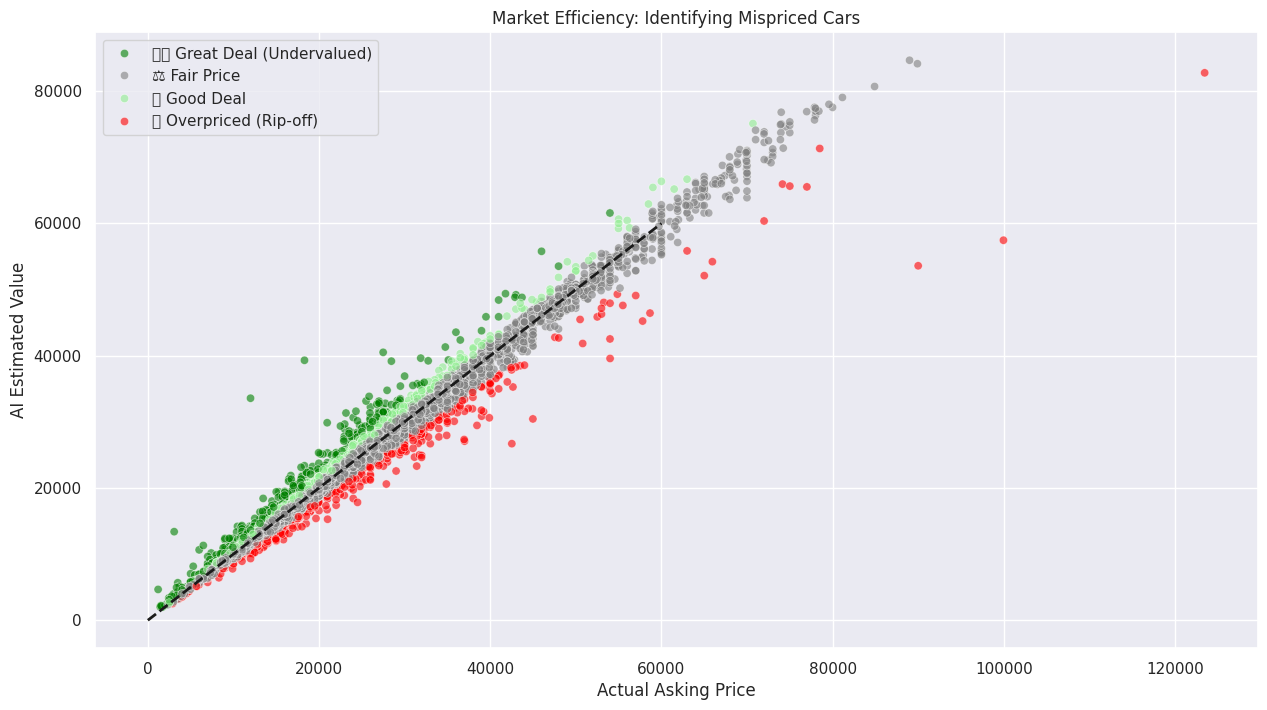

In [30]:
# --- The "Smart Buyer" Tool: Finding Undervalued Cars ---

# 1. Get Predictions for the entire dataset (or just the test set)
# We use the model we trained in Option A
all_predictions = rf_model.predict(X) # Make sure X matches your feature set

# 2. Calculate the Difference (Residual)
# Positive Diff = Car is selling for LESS than predicted (Good Deal)
# Negative Diff = Car is selling for MORE than predicted (Bad Deal)
df_deals = df.copy()
df_deals['Predicted_Price'] = all_predictions
df_deals['Diff'] = df_deals['Predicted_Price'] - df_deals['price']
df_deals['Diff_%'] = (df_deals['Diff'] / df_deals['Predicted_Price']) * 100

# 3. Categorize the Deals
def rate_deal(row):
    if row['Diff_%'] > 10:
        return '🔥🔥 Great Deal (Undervalued)'
    elif row['Diff_%'] > 5:
        return '✅ Good Deal'
    elif row['Diff_%'] < -10:
        return '❌ Overpriced (Rip-off)'
    else:
        return '⚖️ Fair Price'

df_deals['Deal_Rating'] = df_deals.apply(rate_deal, axis=1)

# 4. Show the Top 5 Best Deals (e.g., for a 3 Series)
best_deals = df_deals[df_deals['model'].str.strip() == '3 Series'].sort_values(by='Diff_%', ascending=False)

print("--- Top 5 'Hidden Gems' (3 Series) ---")
print(best_deals[['model', 'year', 'mileage', 'price', 'Predicted_Price', 'Deal_Rating']].head(5))

# 5. Visualize the Market Efficiency
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df_deals, x='price', y='Predicted_Price', hue='Deal_Rating',
                palette={'🔥🔥 Great Deal (Undervalued)': 'green', '✅ Good Deal': 'lightgreen',
                         '⚖️ Fair Price': 'grey', '❌ Overpriced (Rip-off)': 'red'},
                alpha=0.6)
# The "Fair Price" line
plt.plot([0, 60000], [0, 60000], 'k--', lw=2)
plt.title('Market Efficiency: Identifying Mispriced Cars')
plt.xlabel('Actual Asking Price')
plt.ylabel('AI Estimated Value')
plt.legend()
plt.show()

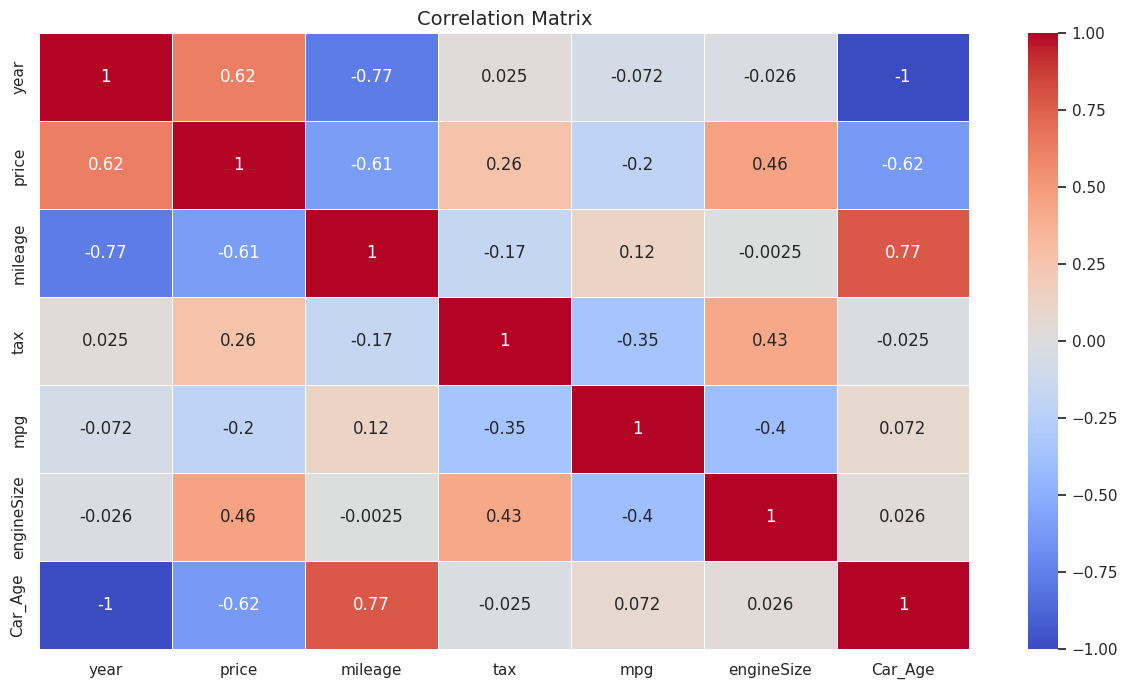

In [29]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You